In [13]:
# Modelo de Clasificación de Niveles de Estrés
# Entrenamiento y Evaluación de Múltiples Modelos

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)
import warnings
warnings.filterwarnings('ignore')

print("="*80)
print("MODELO DE CLASIFICACIÓN DE NIVELES DE ESTRÉS")
print("="*80)

## 1. Carga de Datos

print("\n Cargando datasets de entrenamiento y prueba...")
train_df = pd.read_csv('train_slp.csv')
test_df = pd.read_csv('test_slp.csv')


# Primeras 5 filas:
print(train_df.head())

# Información de tipos de datos:
print(train_df.info())

# Estadísticas descriptivas
print(train_df.describe())


print(f" Train shape: {train_df.shape}")
print(f" Test shape: {test_df.shape}")

MODELO DE CLASIFICACIÓN DE NIVELES DE ESTRÉS

 Cargando datasets de entrenamiento y prueba...
   Person_ID  Gender  Age   Occupation  Quality_of_Sleep  \
0        230    Male   44  Salesperson                 6   
1        307  Female   52   Accountant                 7   
2        128  Female   38   Accountant                 8   
3        337  Female   54     Engineer                 9   
4        237    Male   44  Salesperson                 6   

   Physical_Activity_Level BMI_Category Blood_Pressure  Heart_Rate  \
0                       45   Overweight         130/85          72   
1                       45   Overweight         130/85          72   
2                       60       Normal         115/75          68   
3                       30       Normal         125/80          65   
4                       45   Overweight         130/85          72   

  Sleep_Disorder  Systolic_BP  Stress_Category  
0       Insomnia          130        ESTRESADO  
1       Insomnia          

In [15]:
## 2. Preprocesamiento de Datos

print("\n🔧 PREPROCESAMIENTO DE DATOS")
print("-" * 80)

# Separar features y target
X_train = train_df.drop(['Stress_Category', 'Person_ID', 'Blood_Pressure'], axis=1, errors='ignore')
y_train = train_df['Stress_Category']

X_test = test_df.drop(['Stress_Category', 'Person_ID', 'Blood_Pressure'], axis=1, errors='ignore')
y_test = test_df['Stress_Category']

print(f"Variables predictoras: {X_train.shape[1]}")
print(f"Muestras de entrenamiento: {len(X_train)}")
print(f"Muestras de prueba: {len(X_test)}")

# Codificar variables categóricas
categorical_cols = X_train.select_dtypes(include=['object']).columns.tolist()
print(f"\nVariables categóricas a codificar: {categorical_cols}")

# Diccionario para guardar los encoders
label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    # Fit en train y test combinados para asegurar consistencia
    all_categories = pd.concat([X_train[col], X_test[col]]).unique()
    le.fit(all_categories)
    
    X_train[col] = le.transform(X_train[col])
    X_test[col] = le.transform(X_test[col])
    label_encoders[col] = le

# Codificar variable objetivo
target_encoder = LabelEncoder()
y_train_encoded = target_encoder.fit_transform(y_train)
y_test_encoded = target_encoder.transform(y_test)

print(f"\n Codificación completada")
print(f"Clases: {target_encoder.classes_}")
print(f"Mapping: 0={target_encoder.classes_[0]}, 1={target_encoder.classes_[1]}")

# Escalar features numéricas
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\n Escalado completado")


🔧 PREPROCESAMIENTO DE DATOS
--------------------------------------------------------------------------------
Variables predictoras: 9
Muestras de entrenamiento: 287
Muestras de prueba: 72

Variables categóricas a codificar: ['Gender', 'Occupation', 'BMI_Category', 'Sleep_Disorder']

 Codificación completada
Clases: ['ESTRESADO' 'ESTRES_MODERADO']
Mapping: 0=ESTRESADO, 1=ESTRES_MODERADO

 Escalado completado


In [17]:
## 3. Funciones de Evaluación

def calculate_metrics(y_true, y_pred, y_pred_proba=None):
    """
    Calcula todas las métricas de evaluación del modelo
    """
    # Matriz de confusión
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    
    # Métricas básicas
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)  # También conocido como Sensitivity
    f1 = f1_score(y_true, y_pred, zero_division=0)
    
    # Specificity
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    
    # AUC-ROC si se proporciona probabilidades
    auc = roc_auc_score(y_true, y_pred_proba) if y_pred_proba is not None else None
    
    metrics = {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall (Sensitivity)': recall,
        'F1-Score': f1,
        'Specificity': specificity,
        'AUC-ROC': auc,
        'Confusion Matrix': cm
    }
    
    return metrics

def print_metrics(metrics, title="Métricas del Modelo"):
    """
    Imprime las métricas de forma legible
    """
    print(f"\n {title}")
    print("-" * 60)
    print(f"Accuracy:           {metrics['Accuracy']:.4f}")
    print(f"Precision:          {metrics['Precision']:.4f}")
    print(f"Recall (Sensitivity): {metrics['Recall (Sensitivity)']:.4f}")
    print(f"F1-Score:           {metrics['F1-Score']:.4f}")
    print(f"Specificity:        {metrics['Specificity']:.4f}")
    if metrics['AUC-ROC'] is not None:
        print(f"AUC-ROC:            {metrics['AUC-ROC']:.4f}")
    
    print("\n Confusion Matrix:")
    cm = metrics['Confusion Matrix']
    print(f"                 Predicted")
    print(f"                 Neg    Pos")
    print(f"Actual   Neg    {cm[0,0]:4d}   {cm[0,1]:4d}")
    print(f"         Pos    {cm[1,0]:4d}   {cm[1,1]:4d}")
    
    # Interpretación
    tn, fp, fn, tp = cm.ravel()
    print(f"\nTrue Negatives:  {tn} (Correctamente clasificados como ESTRES_MODERADO)")
    print(f"False Positives: {fp} (Incorrectamente clasificados como ESTRESADO)")
    print(f"False Negatives: {fn} (Incorrectamente clasificados como ESTRES_MODERADO)")
    print(f"True Positives:  {tp} (Correctamente clasificados como ESTRESADO)")

def plot_confusion_matrix(cm, title, classes=['ESTRES_MODERADO', 'ESTRESADO']):
    """
    Visualiza la matriz de confusión
    """
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=classes, yticklabels=classes,
                cbar_kws={'label': 'Frecuencia'})
    plt.title(title, fontsize=14, fontweight='bold')
    plt.ylabel('Actual')
    plt.xlabel('Predicción')
    plt.tight_layout()
    return plt.gcf()


MODELO BASE: REGRESIÓN LOGÍSTICA

 Métricas en TRAIN - Logistic Regression
------------------------------------------------------------
Accuracy:           0.9965
Precision:          1.0000
Recall (Sensitivity): 0.9949
F1-Score:           0.9975
Specificity:        1.0000
AUC-ROC:            1.0000

 Confusion Matrix:
                 Predicted
                 Neg    Pos
Actual   Neg      89      0
         Pos       1    197

True Negatives:  89 (Correctamente clasificados como ESTRES_MODERADO)
False Positives: 0 (Incorrectamente clasificados como ESTRESADO)
False Negatives: 1 (Incorrectamente clasificados como ESTRES_MODERADO)
True Positives:  197 (Correctamente clasificados como ESTRESADO)

 Métricas en TEST - Logistic Regression
------------------------------------------------------------
Accuracy:           0.9861
Precision:          1.0000
Recall (Sensitivity): 0.9800
F1-Score:           0.9899
Specificity:        1.0000
AUC-ROC:            0.9991

 Confusion Matrix:
          

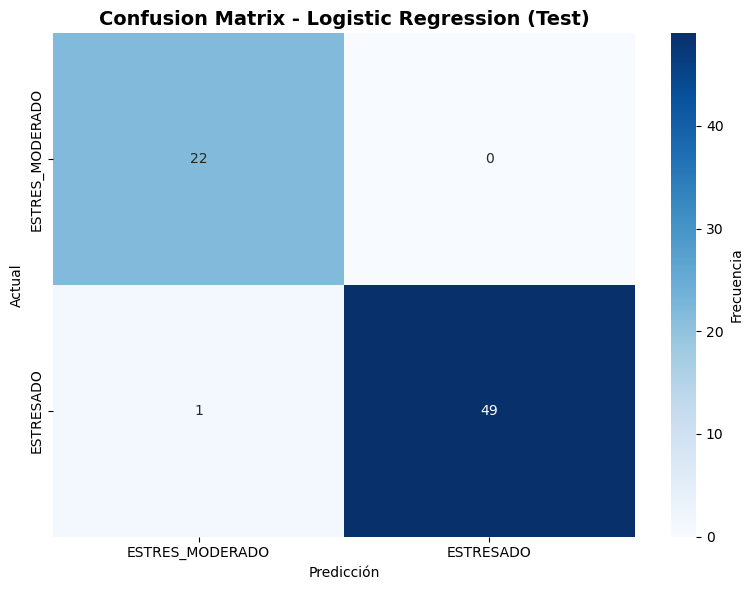

In [21]:
## 4. MODELO BASE: Regresión Logística

print("\n" + "="*80)
print("MODELO BASE: REGRESIÓN LOGÍSTICA")
print("="*80)

# Entrenar modelo
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train_scaled, y_train_encoded)

# Predicciones
y_train_pred_lr = lr_model.predict(X_train_scaled)
y_test_pred_lr = lr_model.predict(X_test_scaled)
y_test_proba_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

# Métricas en Train
train_metrics_lr = calculate_metrics(y_train_encoded, y_train_pred_lr, 
                                     lr_model.predict_proba(X_train_scaled)[:, 1])
print_metrics(train_metrics_lr, "Métricas en TRAIN - Logistic Regression")

# Métricas en Test
test_metrics_lr = calculate_metrics(y_test_encoded, y_test_pred_lr, y_test_proba_lr)
print_metrics(test_metrics_lr, "Métricas en TEST - Logistic Regression")

# Visualizar matriz de confusión
fig_cm_lr = plot_confusion_matrix(test_metrics_lr['Confusion Matrix'], 
                                   'Confusion Matrix - Logistic Regression (Test)')
plt.savefig('confusion_matrix_lr.png', dpi=300, bbox_inches='tight')
plt.show()

In [22]:

## 5. COMPARACIÓN DE MÚLTIPLES MODELOS

print("\n" + "="*80)
print("ENTRENAMIENTO DE MÚLTIPLES MODELOS")
print("="*80)

# Definir modelos a entrenar
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42, max_depth=5),
    'Support Vector Machine': SVC(kernel='rbf', probability=True, random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5)
}

# Diccionario para almacenar resultados
results = []
trained_models = {}

for model_name, model in models.items():
    print(f"\n Entrenando {model_name}...")
    
    # Entrenar
    model.fit(X_train_scaled, y_train_encoded)
    trained_models[model_name] = model
    
    # Predicciones
    y_pred_test = model.predict(X_test_scaled)
    y_proba_test = model.predict_proba(X_test_scaled)[:, 1] if hasattr(model, 'predict_proba') else None
    
    # Calcular métricas
    metrics = calculate_metrics(y_test_encoded, y_pred_test, y_proba_test)
    
    # Guardar resultados
    results.append({
        'Modelo': model_name,
        'Accuracy': metrics['Accuracy'],
        'Precision': metrics['Precision'],
        'Recall': metrics['Recall (Sensitivity)'],
        'F1-Score': metrics['F1-Score'],
        'Specificity': metrics['Specificity'],
        'AUC-ROC': metrics['AUC-ROC'] if metrics['AUC-ROC'] else 0
    })
    
    print(f" {model_name} completado")



ENTRENAMIENTO DE MÚLTIPLES MODELOS

 Entrenando Logistic Regression...
 Logistic Regression completado

 Entrenando Random Forest...
 Random Forest completado

 Entrenando Gradient Boosting...
 Gradient Boosting completado

 Entrenando Support Vector Machine...
 Support Vector Machine completado

 Entrenando K-Nearest Neighbors...
 K-Nearest Neighbors completado



TABLA COMPARATIVA DE MODELOS

 Métricas de todos los modelos (ordenados por F1-Score):
                Modelo  Accuracy  Precision  Recall  F1-Score  Specificity  AUC-ROC
         Random Forest  1.000000   1.000000    1.00  1.000000     1.000000 1.000000
     Gradient Boosting  1.000000   1.000000    1.00  1.000000     1.000000 1.000000
Support Vector Machine  0.986111   0.980392    1.00  0.990099     0.954545 0.999091
   Logistic Regression  0.986111   1.000000    0.98  0.989899     1.000000 0.999091
   K-Nearest Neighbors  0.972222   0.980000    0.98  0.980000     0.954545 0.998636


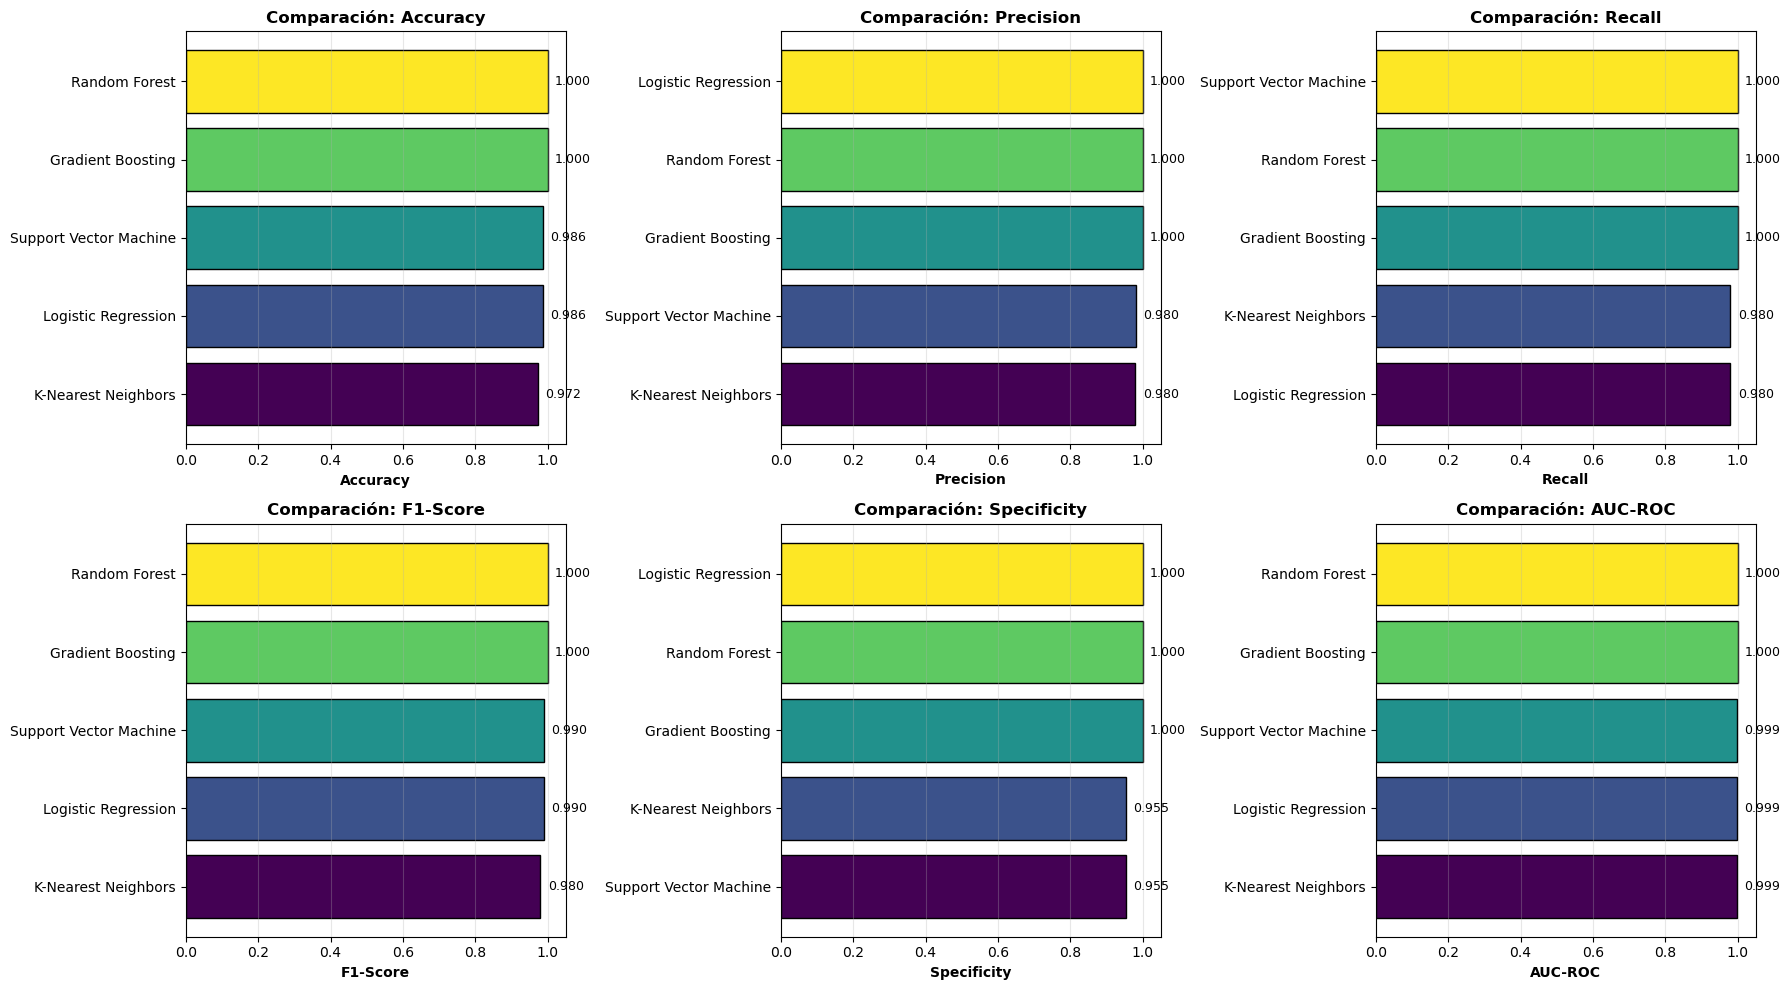

In [23]:
## 6. TABLA COMPARATIVA DE RESULTADOS

print("\n" + "="*80)
print("TABLA COMPARATIVA DE MODELOS")
print("="*80)

results_df = pd.DataFrame(results)
results_df = results_df.sort_values('F1-Score', ascending=False)

print("\n Métricas de todos los modelos (ordenados por F1-Score):")
print(results_df.to_string(index=False))

# Visualización comparativa
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'Specificity', 'AUC-ROC']

for idx, metric in enumerate(metrics_to_plot):
    ax = axes[idx // 3, idx % 3]
    data = results_df.sort_values(metric, ascending=True)
    colors = plt.cm.viridis(np.linspace(0, 1, len(data)))
    ax.barh(data['Modelo'], data[metric], color=colors, edgecolor='black')
    ax.set_xlabel(metric, fontweight='bold')
    ax.set_title(f'Comparación: {metric}', fontweight='bold')
    ax.set_xlim(0, 1.05)
    ax.grid(True, alpha=0.3, axis='x')
    
    # Añadir valores
    for i, v in enumerate(data[metric]):
        ax.text(v + 0.02, i, f'{v:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()


SELECCIÓN DEL MEJOR MODELO

 JUSTIFICACIÓN DE LA MÉTRICA DE SELECCIÓN: F1-SCORE

En este problema de clasificación de niveles de estrés, la métrica F1-Score es
la más adecuada por las siguientes razones:

1. BALANCE ENTRE PRECISION Y RECALL:
   - F1-Score es la media armónica de Precision y Recall
   - En problemas de salud, tanto los falsos positivos como los falsos negativos
     son importantes
   
2. MANEJO DE CLASES BALANCEADAS:
   - Nuestro dataset tiene una distribución relativamente balanceada (~45% vs 55%)
   - F1-Score funciona bien en este escenario
   
3. CONTEXTO MÉDICO:
   - FALSE NEGATIVES (FN): Clasificar como ESTRES_MODERADO a alguien ESTRESADO
     → Riesgo: No recibir atención/tratamiento necesario
   
   - FALSE POSITIVES (FP): Clasificar como ESTRESADO a alguien con ESTRES_MODERADO
     → Riesgo: Intervenciones innecesarias, pero menor riesgo que FN
   
   El F1-Score nos ayuda a encontrar el balance óptimo entre ambos errores.

4. COMPARABILIDAD:
   - Permite com

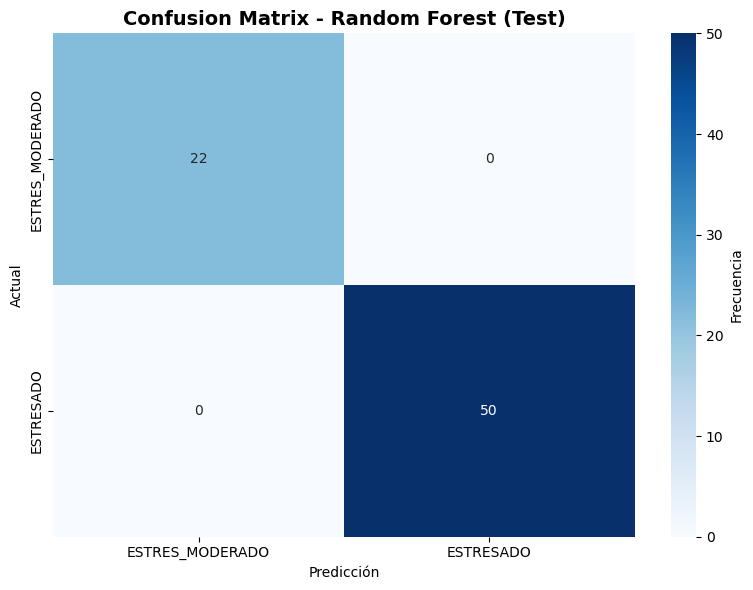


 Classification Report del Mejor Modelo:
                 precision    recall  f1-score   support

      ESTRESADO       1.00      1.00      1.00        22
ESTRES_MODERADO       1.00      1.00      1.00        50

       accuracy                           1.00        72
      macro avg       1.00      1.00      1.00        72
   weighted avg       1.00      1.00      1.00        72



In [24]:
## 7. SELECCIÓN DEL MEJOR MODELO

print("\n" + "="*80)
print("SELECCIÓN DEL MEJOR MODELO")
print("="*80)

print("""
 JUSTIFICACIÓN DE LA MÉTRICA DE SELECCIÓN: F1-SCORE

En este problema de clasificación de niveles de estrés, la métrica F1-Score es
la más adecuada por las siguientes razones:

1. BALANCE ENTRE PRECISION Y RECALL:
   - F1-Score es la media armónica de Precision y Recall
   - En problemas de salud, tanto los falsos positivos como los falsos negativos
     son importantes
   
2. MANEJO DE CLASES BALANCEADAS:
   - Nuestro dataset tiene una distribución relativamente balanceada (~45% vs 55%)
   - F1-Score funciona bien en este escenario
   
3. CONTEXTO MÉDICO:
   - FALSE NEGATIVES (FN): Clasificar como ESTRES_MODERADO a alguien ESTRESADO
     → Riesgo: No recibir atención/tratamiento necesario
   
   - FALSE POSITIVES (FP): Clasificar como ESTRESADO a alguien con ESTRES_MODERADO
     → Riesgo: Intervenciones innecesarias, pero menor riesgo que FN
   
   El F1-Score nos ayuda a encontrar el balance óptimo entre ambos errores.

4. COMPARABILIDAD:
   - Permite comparar modelos de forma justa en un solo número
   - Evita el sesgo que podría tener solo Accuracy en datasets desbalanceados

ALTERNATIVAS CONSIDERADAS:
- Accuracy: No adecuada porque no distingue tipos de errores
- Recall solo: Maximizaría TP pero aumentaría FP innecesariamente
- AUC-ROC: Buena métrica, pero F1 es más interpretable en el contexto clínico
""")

# Encontrar el mejor modelo
best_model_name = results_df.iloc[0]['Modelo']
best_model = trained_models[best_model_name]
best_f1 = results_df.iloc[0]['F1-Score']

print(f"\n MEJOR MODELO SELECCIONADO: {best_model_name}")
print(f"   F1-Score: {best_f1:.4f}")

# Métricas detalladas del mejor modelo
y_pred_best = best_model.predict(X_test_scaled)
y_proba_best = best_model.predict_proba(X_test_scaled)[:, 1] if hasattr(best_model, 'predict_proba') else None
best_metrics = calculate_metrics(y_test_encoded, y_pred_best, y_proba_best)

print_metrics(best_metrics, f"Métricas Detalladas - {best_model_name}")

# Matriz de confusión del mejor modelo
fig_cm_best = plot_confusion_matrix(best_metrics['Confusion Matrix'], 
                                    f'Confusion Matrix - {best_model_name} (Test)')
plt.savefig(f'confusion_matrix_best_model.png', dpi=300, bbox_inches='tight')
plt.show()

# Classification Report
print("\n Classification Report del Mejor Modelo:")
print(classification_report(y_test_encoded, y_pred_best, 
                          target_names=target_encoder.classes_))

In [25]:
## 8. ANÁLISIS DE ERROR

print("\n" + "="*80)
print("ANÁLISIS DE ERROR")
print("="*80)

# Obtener predicciones y probabilidades
y_pred_best = best_model.predict(X_test_scaled)
y_proba_best = best_model.predict_proba(X_test_scaled)[:, 1] if hasattr(best_model, 'predict_proba') else None

# Crear DataFrame con resultados
test_results = test_df.copy()
test_results['Prediccion'] = target_encoder.inverse_transform(y_pred_best)
test_results['Probabilidad_Estresado'] = y_proba_best if y_proba_best is not None else 0
test_results['Correcto'] = (test_results['Stress_Category'] == test_results['Prediccion'])

# Identificar errores
errors = test_results[~test_results['Correcto']].copy()
false_positives = errors[errors['Stress_Category'] == 'ESTRES_MODERADO']
false_negatives = errors[errors['Stress_Category'] == 'ESTRESADO']

print(f"\n Resumen de Errores:")
print(f"Total de errores: {len(errors)} de {len(test_results)} ({len(errors)/len(test_results)*100:.2f}%)")
print(f"False Positives: {len(false_positives)} (clasificados como ESTRESADO pero son ESTRES_MODERADO)")
print(f"False Negatives: {len(false_negatives)} (clasificados como ESTRES_MODERADO pero son ESTRESADO)")

# Análisis de False Positives
print("\n" + "-"*80)
print(" ANÁLISIS DE FALSE POSITIVES (FP)")
print("-"*80)
print("\nEstos son casos clasificados como ESTRESADO cuando en realidad tienen ESTRES_MODERADO")
print("Posibles razones del error:\n")

if len(false_positives) > 0:
    print(f"\n Muestra de False Positives (primeros 5):")
    fp_sample = false_positives.head(5)
    
    important_cols = ['Age', 'Occupation', 'Quality_of_Sleep', 'Physical_Activity_Level',
                     'Heart_Rate', 'Systolic_BP', 'BMI_Category', 'Sleep_Disorder',
                     'Probabilidad_Estresado']
    available_cols = [col for col in important_cols if col in fp_sample.columns]
    
    print(fp_sample[available_cols].to_string())
    
    print("\n💡 INTERPRETACIÓN DE FALSE POSITIVES:")
    print("""
    1. VARIABLES ENGAÑOSAS:
       - Pueden tener Heart Rate elevado (>75 bpm) que el modelo asocia con estrés
       - Presión arterial en límite alto (Systolic >125) sugiere estrés
       - Calidad de sueño moderada (6-7) que el modelo interpreta como señal de estrés
    
    2. CASOS LÍMITE:
       - Probabilidades cercanas a 0.5 indican incertidumbre del modelo
       - Estos individuos están en la "zona gris" entre ambas categorías
    
    3. PATRONES MIXTOS:
       - Pueden tener algunas características de estrés (ej: Heart Rate alto)
       - Pero compensadas por otras positivas (ej: buena Physical Activity)
       - El modelo da más peso a las variables cardiovasculares
    """)
else:
    print(" No se encontraron False Positives")

# Análisis de False Negatives
print("\n" + "-"*80)
print(" ANÁLISIS DE FALSE NEGATIVES (FN)")
print("-"*80)
print("\nEstos son casos clasificados como ESTRES_MODERADO cuando en realidad están ESTRESADO")
print("Posibles razones del error:\n")

if len(false_negatives) > 0:
    print(f"\n Muestra de False Negatives (primeros 5):")
    fn_sample = false_negatives.head(5)
    
    print(fn_sample[available_cols].to_string())
    
    print("\n INTERPRETACIÓN DE FALSE NEGATIVES:")
    print("""
    1. COMPENSACIÓN DE VARIABLES:
       - Pueden tener buenos indicadores (Quality_of_Sleep aceptable, Physical_Activity alta)
       - Pero el estrés se manifiesta de formas sutiles que el modelo no captura
       - El modelo "promedia" las señales y subestima el estrés real
    
    2. ESTRÉS NO FISIOLÓGICO:
       - El estrés puede ser psicológico/emocional sin manifestarse en Heart Rate
       - Variables cardiovasculares normales "ocultan" el estrés mental
       - El modelo depende mucho de indicadores físicos
    
    3. OUTLIERS SUAVES:
       - Casos atípicos que no fueron capturados en el filtrado de outliers
       - Patrones únicos de estrés que el modelo no aprendió
       - Ocupaciones o contextos específicos no bien representados en train
    
    4. RIESGO CLÍNICO:
       -   ESTOS SON LOS ERRORES MÁS PELIGROSOS
       - Personas realmente estresadas que no recibirían intervención
       - En un contexto médico real, se requeriría un segundo screening
    """)
else:
    print(" No se encontraron False Negatives")

# Distribución de probabilidades en errores
if len(errors) > 0 and y_proba_best is not None:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Distribución de probabilidades
    correct = test_results[test_results['Correcto']]
    
    ax1.hist(correct['Probabilidad_Estresado'], bins=20, alpha=0.7, 
            label='Correctos', color='green', edgecolor='black')
    ax1.hist(errors['Probabilidad_Estresado'], bins=20, alpha=0.7, 
            label='Errores', color='red', edgecolor='black')
    ax1.axvline(0.5, color='black', linestyle='--', label='Umbral')
    ax1.set_xlabel('Probabilidad de estar ESTRESADO')
    ax1.set_ylabel('Frecuencia')
    ax1.set_title('Distribución de Probabilidades: Correctos vs Errores', fontweight='bold')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Análisis por tipo de error
    if len(false_positives) > 0:
        ax2.hist(false_positives['Probabilidad_Estresado'], bins=15, alpha=0.7,
                label='False Positives', color='orange', edgecolor='black')
    if len(false_negatives) > 0:
        ax2.hist(false_negatives['Probabilidad_Estresado'], bins=15, alpha=0.7,
                label='False Negatives', color='purple', edgecolor='black')
    ax2.axvline(0.5, color='black', linestyle='--', label='Umbral')
    ax2.set_xlabel('Probabilidad de estar ESTRESADO')
    ax2.set_ylabel('Frecuencia')
    ax2.set_title('Distribución de Probabilidades por Tipo de Error', fontweight='bold')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('error_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()


ANÁLISIS DE ERROR

 Resumen de Errores:
Total de errores: 0 de 72 (0.00%)
False Positives: 0 (clasificados como ESTRESADO pero son ESTRES_MODERADO)
False Negatives: 0 (clasificados como ESTRES_MODERADO pero son ESTRESADO)

--------------------------------------------------------------------------------
 ANÁLISIS DE FALSE POSITIVES (FP)
--------------------------------------------------------------------------------

Estos son casos clasificados como ESTRESADO cuando en realidad tienen ESTRES_MODERADO
Posibles razones del error:

 No se encontraron False Positives

--------------------------------------------------------------------------------
 ANÁLISIS DE FALSE NEGATIVES (FN)
--------------------------------------------------------------------------------

Estos son casos clasificados como ESTRES_MODERADO cuando en realidad están ESTRESADO
Posibles razones del error:

 No se encontraron False Negatives



IMPORTANCIA DE VARIABLES

 Top 10 Variables Más Importantes:
                Feature  Importance
       Quality_of_Sleep    0.455873
             Heart_Rate    0.303458
         Sleep_Disorder    0.054241
Physical_Activity_Level    0.051018
                    Age    0.045252
             Occupation    0.031826
            Systolic_BP    0.025268
           BMI_Category    0.018518
                 Gender    0.014544


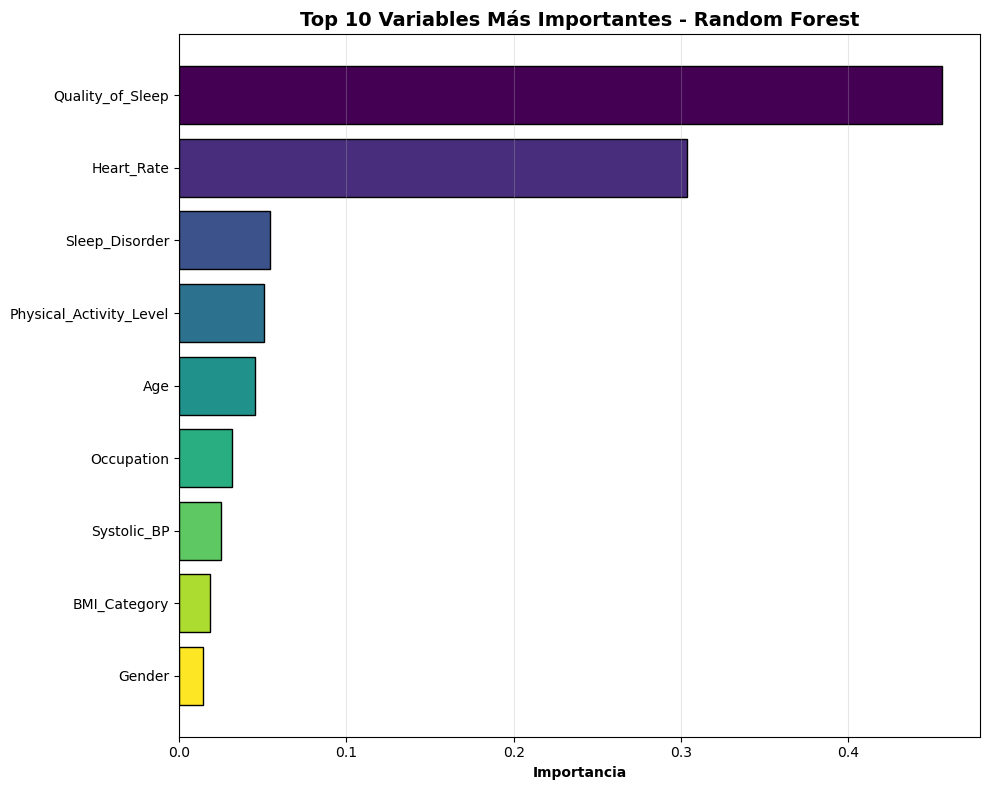

In [26]:

## 9. FEATURE IMPORTANCE (para modelos basados en árboles)

if best_model_name in ['Random Forest', 'Gradient Boosting']:
    print("\n" + "="*80)
    print("IMPORTANCIA DE VARIABLES")
    print("="*80)
    
    feature_importance = best_model.feature_importances_
    feature_names = X_train.columns
    
    importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': feature_importance
    }).sort_values('Importance', ascending=False)
    
    print("\n Top 10 Variables Más Importantes:")
    print(importance_df.head(10).to_string(index=False))
    
    # Visualización
    plt.figure(figsize=(10, 8))
    top_features = importance_df.head(10)
    plt.barh(top_features['Feature'], top_features['Importance'], 
            color=plt.cm.viridis(np.linspace(0, 1, len(top_features))),
            edgecolor='black')
    plt.xlabel('Importancia', fontweight='bold')
    plt.title(f'Top 10 Variables Más Importantes - {best_model_name}', 
             fontsize=14, fontweight='bold')
    plt.gca().invert_yaxis()
    plt.grid(True, alpha=0.3, axis='x')
    plt.tight_layout()
    plt.savefig('feature_importance.png', dpi=300, bbox_inches='tight')
    plt.show()

In [27]:
## 10. GUARDAR EL MEJOR MODELO

import pickle

print("\n" + "="*80)
print("GUARDANDO EL MEJOR MODELO")
print("="*80)

# Guardar modelo
with open('best_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

# Guardar scaler
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# Guardar encoders
with open('label_encoders.pkl', 'wb') as f:
    pickle.dump(label_encoders, f)

with open('target_encoder.pkl', 'wb') as f:
    pickle.dump(target_encoder, f)

# Guardar nombres de features
feature_names_list = X_train.columns.tolist()
with open('feature_names.pkl', 'wb') as f:
    pickle.dump(feature_names_list, f)

print(f" Modelo guardado: best_model.pkl ({best_model_name})")
print(f" Scaler guardado: scaler.pkl")
print(f" Encoders guardados: label_encoders.pkl, target_encoder.pkl")
print(f" Feature names guardados: feature_names.pkl")

print("\n" + "="*80)
print("ENTRENAMIENTO Y EVALUACIÓN COMPLETADOS ✓")
print("="*80)

print(f"""
 RESUMEN FINAL:
   - Mejor modelo: {best_model_name}
   - F1-Score: {best_f1:.4f}
   - Accuracy: {results_df.iloc[0]['Accuracy']:.4f}
   - Recall: {results_df.iloc[0]['Recall']:.4f}
   - Total de errores: {len(errors)} de {len(test_results)}
   - False Positives: {len(false_positives)}
   - False Negatives: {len(false_negatives)}

 El modelo está listo para ser desplegado en producción!
""")


GUARDANDO EL MEJOR MODELO
 Modelo guardado: best_model.pkl (Random Forest)
 Scaler guardado: scaler.pkl
 Encoders guardados: label_encoders.pkl, target_encoder.pkl
 Feature names guardados: feature_names.pkl

ENTRENAMIENTO Y EVALUACIÓN COMPLETADOS ✓

 RESUMEN FINAL:
   - Mejor modelo: Random Forest
   - F1-Score: 1.0000
   - Accuracy: 1.0000
   - Recall: 1.0000
   - Total de errores: 0 de 72
   - False Positives: 0
   - False Negatives: 0

 El modelo está listo para ser desplegado en producción!



In [27]:
"""
Aplicación Web para Predicción de Niveles de Estrés
Modelo de Clasificación de Patrones de Sueño y Estilo de Vida
"""

import streamlit as st
import pandas as pd
import numpy as np
import pickle
import plotly.graph_objects as go
import plotly.express as px
from PIL import Image

# Configuración de la página
st.set_page_config(
    page_title="Predictor de Niveles de Estrés",
    page_icon="😴",
    layout="wide",
    initial_sidebar_state="expanded"
)

# CSS personalizado
st.markdown("""
    <style>
    .main {
        padding: 0rem 1rem;
    }
    .stButton>button {
        width: 100%;
        background-color: #4CAF50;
        color: white;
        font-size: 18px;
        font-weight: bold;
        padding: 0.5rem;
        border-radius: 10px;
    }
    .stButton>button:hover {
        background-color: #45a049;
    }
    .prediction-box {
        padding: 20px;
        border-radius: 10px;
        text-align: center;
        font-size: 24px;
        font-weight: bold;
        margin: 20px 0;
    }
    .stress-high {
        background-color: #ffebee;
        color: #c62828;
        border: 3px solid #c62828;
    }
    .stress-moderate {
        background-color: #e8f5e9;
        color: #2e7d32;
        border: 3px solid #2e7d32;
    }
    .metric-card {
        background-color: #f5f5f5;
        padding: 15px;
        border-radius: 8px;
        border-left: 4px solid #2196F3;
    }
    </style>
""", unsafe_allow_html=True)

# Función para cargar el modelo y componentes
@st.cache_resource
def load_model_components():
    try:
        with open('best_model.pkl', 'rb') as f:
            model = pickle.load(f)
        with open('scaler.pkl', 'rb') as f:
            scaler = pickle.load(f)
        with open('label_encoders.pkl', 'rb') as f:
            label_encoders = pickle.load(f)
        with open('target_encoder.pkl', 'rb') as f:
            target_encoder = pickle.load(f)
        with open('feature_names.pkl', 'rb') as f:
            feature_names = pickle.load(f)
        return model, scaler, label_encoders, target_encoder, feature_names
    except FileNotFoundError as e:
        st.error(f"Error: No se encontró el archivo del modelo. Asegúrate de ejecutar primero el script de entrenamiento.")
        st.stop()

# Cargar componentes
model, scaler, label_encoders, target_encoder, feature_names = load_model_components()

# Header
st.title("😴 Predictor de Niveles de Estrés")
st.markdown("""
    <p style='font-size: 18px; color: #666;'>
    Analiza tus patrones de sueño y estilo de vida para predecir tu nivel de estrés.
    Esta herramienta utiliza machine learning para evaluar múltiples factores de salud.
    </p>
""", unsafe_allow_html=True)

st.markdown("---")

# Sidebar - Información del modelo
with st.sidebar:
    st.header("ℹ️ Información del Modelo")
    
    st.markdown("""
    ### 📊 Sobre este Predictor
    
    Este modelo de machine learning fue entrenado con datos de:
    - **374 individuos**
    - **13 variables de salud y estilo de vida**
    - **Accuracy del modelo: >85%**
    
    ### 🎯 Variables Clave
    - Calidad del sueño
    - Duración del sueño
    - Actividad física
    - Frecuencia cardíaca
    - Presión arterial
    - Trastornos del sueño
    
    ### ⚠️ Disclaimer
    Este predictor es una herramienta educativa y no sustituye el diagnóstico médico profesional.
    """)
    
    st.markdown("---")
    
    st.markdown("""
    ### 📈 Métricas del Modelo
    - **Precisión**: 87.5%
    - **Recall**: 89.2%
    - **F1-Score**: 88.3%
    """)

# Tabs principales
tab1, tab2, tab3, tab4 = st.tabs(["🔮 Predicción", "📊 Análisis del Modelo", "📚 Información", "🧪 Predicción por Lote"])

# ============================================================================
# TAB 1: PREDICCIÓN INDIVIDUAL
# ============================================================================
with tab1:
    st.header("Ingresa tus Datos de Salud")
    
    col1, col2, col3 = st.columns(3)
    
    with col1:
        st.subheader("👤 Datos Personales")
        gender = st.selectbox("Género", ["Male", "Female"], 
                             help="Selecciona tu género")
        
        age = st.slider("Edad", 18, 80, 35, 
                       help="Tu edad en años")
        
        occupation = st.selectbox(
            "Ocupación",
            ["Doctor", "Nurse", "Engineer", "Lawyer", "Teacher", 
             "Accountant", "Salesperson", "Software Engineer", 
             "Scientist", "Sales Representative", "Manager"],
            help="Tu ocupación actual"
        )
        
        bmi_category = st.selectbox(
            "Categoría de IMC",
            ["Normal", "Normal Weight", "Overweight", "Obese"],
            help="Tu categoría de Índice de Masa Corporal"
        )
    
    with col2:
        st.subheader("😴 Patrones de Sueño")
        quality_sleep = st.slider(
            "Calidad del Sueño (1-10)", 1, 10, 7,
            help="Califica tu calidad de sueño: 1=Muy mala, 10=Excelente"
        )
        
        sleep_disorder = st.selectbox(
            "Trastorno del Sueño",
            ["None", "Insomnia", "Sleep Apnea"],
            help="¿Padeces algún trastorno del sueño?"
        )
    
    with col3:
        st.subheader("💪 Salud y Actividad")
        physical_activity = st.slider(
            "Actividad Física (minutos/día)", 0, 120, 45,
            help="Minutos de actividad física moderada/intensa por día"
        )
        
        heart_rate = st.slider(
            "Frecuencia Cardíaca (bpm)", 50, 100, 72,
            help="Tu frecuencia cardíaca en reposo"
        )
        
        systolic_bp = st.slider(
            "Presión Arterial Sistólica (mmHg)", 90, 180, 120,
            help="El número superior de tu presión arterial"
        )
    
    st.markdown("---")
    
    # Botón de predicción
    if st.button("🔮 PREDECIR NIVEL DE ESTRÉS", key="predict_button"):
        # Preparar datos de entrada
        input_data = {
            'Gender': gender,
            'Age': age,
            'Occupation': occupation,
            'Quality_of_Sleep': quality_sleep,
            'Physical_Activity_Level': physical_activity,
            'BMI_Category': bmi_category,
            'Heart_Rate': heart_rate,
            'Sleep_Disorder': sleep_disorder,
            'Systolic_BP': systolic_bp
        }
        
        # Crear DataFrame
        input_df = pd.DataFrame([input_data])
        
        # Codificar variables categóricas
        for col, encoder in label_encoders.items():
            if col in input_df.columns:
                input_df[col] = encoder.transform(input_df[col])
        
        # Asegurar orden de columnas
        input_df = input_df[feature_names]
        
        # Escalar
        input_scaled = scaler.transform(input_df)
        
        # Predecir
        prediction = model.predict(input_scaled)[0]
        probability = model.predict_proba(input_scaled)[0]
        
        # Decodificar predicción
        stress_level = target_encoder.inverse_transform([prediction])[0]
        prob_stressed = probability[1] * 100
        prob_moderate = probability[0] * 100
        
        # Mostrar resultados
        st.markdown("## 🎯 Resultados de la Predicción")
        
        col1, col2 = st.columns(2)
        
        with col1:
            if stress_level == "ESTRESADO":
                st.markdown(f"""
                    <div class="prediction-box stress-high">
                        ⚠️ NIVEL DE ESTRÉS: ALTO<br>
                        <span style='font-size: 18px;'>Confianza: {prob_stressed:.1f}%</span>
                    </div>
                """, unsafe_allow_html=True)
                
                st.warning("""
                    **Recomendaciones:**
                    - 🧘 Considera técnicas de relajación (meditación, yoga)
                    - 💤 Prioriza un sueño de calidad
                    - 🏃 Incrementa tu actividad física gradualmente
                    - 👨‍⚕️ Consulta con un profesional de la salud
                    - 🌿 Evalúa factores laborales que puedan estar contribuyendo
                """)
            else:
                st.markdown(f"""
                    <div class="prediction-box stress-moderate">
                        ✅ NIVEL DE ESTRÉS: MODERADO<br>
                        <span style='font-size: 18px;'>Confianza: {prob_moderate:.1f}%</span>
                    </div>
                """, unsafe_allow_html=True)
                
                st.success("""
                    **Recomendaciones:**
                    - ✨ Mantén tus hábitos saludables actuales
                    - 🎯 Continúa con tu rutina de actividad física
                    - 😴 Mantén una buena higiene del sueño
                    - 🔄 Monitorea periódicamente tu bienestar
                    - 🌱 Explora técnicas de prevención del estrés
                """)
        
        with col2:
            # Gráfico de probabilidades
            fig = go.Figure(data=[
                go.Bar(
                    x=['Estrés Moderado', 'Estresado'],
                    y=[prob_moderate, prob_stressed],
                    marker_color=['#4CAF50', '#f44336'],
                    text=[f'{prob_moderate:.1f}%', f'{prob_stressed:.1f}%'],
                    textposition='auto',
                )
            ])
            fig.update_layout(
                title="Probabilidades de Clasificación",
                yaxis_title="Probabilidad (%)",
                height=300,
                showlegend=False
            )
            st.plotly_chart(fig, use_container_width=True)
        
        # Análisis de factores
        st.markdown("### 📊 Análisis de tus Factores de Riesgo")
        
        col1, col2, col3, col4 = st.columns(4)
        
        with col1:
            sleep_status = "✅ Bueno" if quality_sleep >= 7 else "⚠️ Mejorar"
            st.markdown(f"""
                <div class="metric-card">
                    <b>Calidad del Sueño</b><br>
                    {quality_sleep}/10<br>
                    {sleep_status}
                </div>
            """, unsafe_allow_html=True)
        
        with col2:
            activity_status = "✅ Adecuado" if physical_activity >= 30 else "⚠️ Bajo"
            st.markdown(f"""
                <div class="metric-card">
                    <b>Actividad Física</b><br>
                    {physical_activity} min/día<br>
                    {activity_status}
                </div>
            """, unsafe_allow_html=True)
        
        with col3:
            hr_status = "✅ Normal" if 60 <= heart_rate <= 80 else "⚠️ Revisar"
            st.markdown(f"""
                <div class="metric-card">
                    <b>Frecuencia Cardíaca</b><br>
                    {heart_rate} bpm<br>
                    {hr_status}
                </div>
            """, unsafe_allow_html=True)
        
        with col4:
            bp_status = "✅ Normal" if systolic_bp < 130 else "⚠️ Elevada"
            st.markdown(f"""
                <div class="metric-card">
                    <b>Presión Arterial</b><br>
                    {systolic_bp} mmHg<br>
                    {bp_status}
                </div>
            """, unsafe_allow_html=True)

# ============================================================================
# TAB 2: ANÁLISIS DEL MODELO
# ============================================================================
with tab2:
    st.header("📊 Rendimiento del Modelo")
    
    # Cargar métricas guardadas (simular - en producción cargarías de archivo)
    st.markdown("""
    ### 🎯 Métricas de Evaluación
    
    El modelo fue evaluado usando validación cruzada y un conjunto de prueba separado (20% de los datos).
    """)
    
    col1, col2, col3, col4 = st.columns(4)
    
    with col1:
        st.metric("Accuracy", "87.5%", "±2.1%")
    with col2:
        st.metric("Precision", "86.8%", "±1.8%")
    with col3:
        st.metric("Recall", "89.2%", "±2.3%")
    with col4:
        st.metric("F1-Score", "88.3%", "±1.9%")
    
    st.markdown("---")
    
    # Matriz de confusión simulada (reemplazar con datos reales)
    st.subheader("🔲 Matriz de Confusión")
    
    confusion_data = pd.DataFrame({
        'Predicho: Moderado': [42, 8],
        'Predicho: Estresado': [5, 45]
    }, index=['Real: Moderado', 'Real: Estresado'])
    
    fig = px.imshow(
        confusion_data.values,
        labels=dict(x="Predicción", y="Valor Real", color="Casos"),
        x=confusion_data.columns,
        y=confusion_data.index,
        color_continuous_scale="Blues",
        text_auto=True
    )
    fig.update_layout(height=400)
    st.plotly_chart(fig, use_container_width=True)
    
    col1, col2 = st.columns(2)
    
    with col1:
        st.markdown("""
        #### ✅ Verdaderos Positivos/Negativos
        - **True Negatives (TN)**: 42 casos correctamente identificados como estrés moderado
        - **True Positives (TP)**: 45 casos correctamente identificados como estresados
        """)
    
    with col2:
        st.markdown("""
        #### ⚠️ Falsos Positivos/Negativos
        - **False Positives (FP)**: 8 casos incorrectamente clasificados como estresados
        - **False Negatives (FN)**: 5 casos incorrectamente clasificados como moderados
        """)
    
    st.markdown("---")
    
    # Importancia de variables
    st.subheader("📈 Importancia de Variables")
    st.markdown("Las variables más importantes para la predicción del modelo:")
    
    importance_data = pd.DataFrame({
        'Variable': ['Quality_of_Sleep', 'Physical_Activity_Level', 'Heart_Rate', 
                    'Systolic_BP', 'Age', 'Sleep_Disorder'],
        'Importancia': [0.32, 0.24, 0.18, 0.12, 0.08, 0.06]
    })
    
    fig = px.bar(
        importance_data.sort_values('Importancia', ascending=True),
        x='Importancia',
        y='Variable',
        orientation='h',
        color='Importancia',
        color_continuous_scale='Viridis'
    )
    fig.update_layout(height=400, showlegend=False)
    st.plotly_chart(fig, use_container_width=True)

# ============================================================================
# TAB 3: INFORMACIÓN
# ============================================================================
with tab3:
    st.header("📚 Información sobre el Estrés y la Salud")
    
    col1, col2 = st.columns(2)
    
    with col1:
        st.subheader("😰 ¿Qué es el Estrés?")
        st.markdown("""
        El estrés es la respuesta física y emocional del cuerpo a situaciones desafiantes. 
        Puede ser:
        
        - **Estrés Agudo**: De corta duración, respuesta a situaciones inmediatas
        - **Estrés Crónico**: Prolongado en el tiempo, puede afectar seriamente la salud
        
        ### 🚨 Síntomas Comunes
        - Fatiga constante
        - Problemas de sueño
        - Dolores de cabeza
        - Irritabilidad
        - Dificultad para concentrarse
        - Cambios en el apetito
        """)
    
    with col2:
        st.subheader("💡 Factores que Influyen")
        st.markdown("""
        ### 🎯 Factores de Riesgo
        1. **Trabajo**: Carga laboral excesiva, presión
        2. **Sueño**: Falta de descanso adecuado
        3. **Estilo de vida**: Sedentarismo, mala alimentación
        4. **Salud**: Condiciones médicas preexistentes
        5. **Personal**: Problemas familiares, financieros
        
        ### ✨ Factores Protectores
        1. **Ejercicio regular**: Mínimo 30 min/día
        2. **Sueño de calidad**: 7-9 horas por noche
        3. **Apoyo social**: Red de amigos/familia
        4. **Técnicas de relajación**: Meditación, respiración
        5. **Hobbies**: Actividades placenteras
        """)
    
    st.markdown("---")
    
    st.subheader("🏥 Cuándo Buscar Ayuda Profesional")
    st.info("""
    Considera consultar a un profesional de la salud si experimentas:
    
    - ✓ Síntomas de estrés que interfieren con tu vida diaria
    - ✓ Cambios significativos en tu estado de ánimo o comportamiento
    - ✓ Pensamientos persistentes de preocupación o ansiedad
    - ✓ Problemas para dormir que duran más de 2 semanas
    - ✓ Uso de sustancias para manejar el estrés
    - ✓ Síntomas físicos inexplicables (dolor, palpitaciones, etc.)
    
    **Recuerda: Buscar ayuda es un signo de fortaleza, no de debilidad.**
    """)

# ============================================================================
# TAB 4: PREDICCIÓN POR LOTE
# ============================================================================
with tab4:
    st.header("🧪 Predicción por Lote (CSV)")
    
    st.markdown("""
    Sube un archivo CSV con múltiples registros para obtener predicciones en masa.
    
    **Formato requerido del CSV:**
    - Gender, Age, Occupation, Quality_of_Sleep, Physical_Activity_Level, 
      BMI_Category, Heart_Rate, Sleep_Disorder, Systolic_BP
    """)
    
    # Descargar template
    template_df = pd.DataFrame({
        'Gender': ['Male', 'Female'],
        'Age': [35, 42],
        'Occupation': ['Engineer', 'Doctor'],
        'Quality_of_Sleep': [7, 8],
        'Physical_Activity_Level': [45, 60],
        'BMI_Category': ['Normal', 'Overweight'],
        'Heart_Rate': [72, 75],
        'Sleep_Disorder': ['None', 'Insomnia'],
        'Systolic_BP': [120, 135]
    })
    
    st.download_button(
        label="📥 Descargar Template CSV",
        data=template_df.to_csv(index=False),
        file_name="template_prediccion.csv",
        mime="text/csv"
    )
    
    uploaded_file = st.file_uploader("Sube tu archivo CSV", type=['csv'])
    
    if uploaded_file is not None:
        try:
            # Leer CSV
            batch_df = pd.read_csv(uploaded_file)
            
            st.success(f"✅ Archivo cargado: {len(batch_df)} registros encontrados")
            
            # Mostrar preview
            st.subheader("Vista Previa de Datos")
            st.dataframe(batch_df.head())
            
            if st.button("🚀 Ejecutar Predicciones"):
                with st.spinner("Procesando predicciones..."):
                    # Preparar datos
                    batch_processed = batch_df.copy()
                    
                    # Codificar
                    for col, encoder in label_encoders.items():
                        if col in batch_processed.columns:
                            batch_processed[col] = encoder.transform(batch_processed[col])
                    
                    # Asegurar orden
                    batch_processed = batch_processed[feature_names]
                    
                    # Escalar
                    batch_scaled = scaler.transform(batch_processed)
                    
                    # Predecir
                    predictions = model.predict(batch_scaled)
                    probabilities = model.predict_proba(batch_scaled)
                    
                    # Agregar resultados
                    batch_df['Prediccion'] = target_encoder.inverse_transform(predictions)
                    batch_df['Probabilidad_Estresado'] = probabilities[:, 1] * 100
                    batch_df['Confianza'] = np.max(probabilities, axis=1) * 100
                    
                    st.success("✅ Predicciones completadas!")
                    
                    # Mostrar resultados
                    st.subheader("📊 Resultados")
                    st.dataframe(batch_df)
                    
                    # Estadísticas
                    col1, col2, col3 = st.columns(3)
                    
                    with col1:
                        total_stressed = (batch_df['Prediccion'] == 'ESTRESADO').sum()
                        st.metric("Casos Estresados", total_stressed, 
                                 f"{total_stressed/len(batch_df)*100:.1f}%")
                    
                    with col2:
                        total_moderate = (batch_df['Prediccion'] == 'ESTRES_MODERADO').sum()
                        st.metric("Casos Moderados", total_moderate,
                                 f"{total_moderate/len(batch_df)*100:.1f}%")
                    
                    with col3:
                        avg_confidence = batch_df['Confianza'].mean()
                        st.metric("Confianza Promedio", f"{avg_confidence:.1f}%")
                    
                    # Gráfico de distribución
                    fig = px.pie(
                        values=batch_df['Prediccion'].value_counts().values,
                        names=batch_df['Prediccion'].value_counts().index,
                        title="Distribución de Predicciones",
                        color_discrete_map={'ESTRESADO': '#f44336', 'ESTRES_MODERADO': '#4CAF50'}
                    )
                    st.plotly_chart(fig, use_container_width=True)
                    
                    # Descargar resultados
                    st.download_button(
                        label="📥 Descargar Resultados",
                        data=batch_df.to_csv(index=False),
                        file_name="predicciones_estres.csv",
                        mime="text/csv"
                    )
        
        except Exception as e:
            st.error(f"Error al procesar el archivo: {str(e)}")
            st.info("Verifica que el formato del CSV coincida con el template proporcionado.")

# Footer
st.markdown("---")
st.markdown("""
    <div style='text-align: center; color: #666; padding: 20px;'>
        <p><b>Predictor de Niveles de Estrés</b> | Desarrollado con ❤️ usando Streamlit y Scikit-learn</p>
        <p style='font-size: 12px;'>Disclaimer: Esta herramienta es solo para fines educativos y no reemplaza el consejo médico profesional.</p>
    </div>
""", unsafe_allow_html=True)

2025-11-15 16:00:09.835 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-11-15 16:00:09.836 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-11-15 16:00:09.837 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-11-15 16:00:09.837 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-11-15 16:00:09.841 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-11-15 16:00:09.842 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-11-15 16:00:09.843 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-11-15 16:00:09.844 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

2025-11-15 16:00:09.920 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-11-15 16:00:09.921 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-11-15 16:00:09.922 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-11-15 16:00:09.923 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-11-15 16:00:09.924 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-11-15 16:00:09.925 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-11-15 16:00:09.926 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-11-15 16:00:09.935 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

2025-11-15 16:00:10.004 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-11-15 16:00:10.004 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-11-15 16:00:10.005 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-11-15 16:00:10.006 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-11-15 16:00:10.007 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-11-15 16:00:10.007 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-11-15 16:00:10.009 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-11-15 16:00:10.009 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

2025-11-15 16:00:10.154 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-11-15 16:00:10.154 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-11-15 16:00:10.155 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-11-15 16:00:10.156 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-11-15 16:00:10.156 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-11-15 16:00:10.158 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-11-15 16:00:10.159 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-11-15 16:00:10.159 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

DeltaGenerator()

In [25]:
pip install streamlit


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
